Training the Model: Transfer Learning Using MobileNetV2

In [1]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = 224

# Load the "Base" Model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the Base Model
base_model.trainable = False

# Build the Final Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Loading Training Dataset

In [2]:
# Loading and Training Script
train_ds = tf.keras.utils.image_dataset_from_directory(
    './train',
    validation_split=0.2,   # Use 20% for validation (checking the model's progress)
    subset="training",      # This creates the Training set
    seed=123,               # A "key" to make sure the split is the same every time
    image_size=(224, 224),  # Matches our resizing step
    batch_size=32           # The model looks at 32 images at a time
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './train',
    validation_split=0.2,
    subset="validation",    # This creates the Validation set
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Speed up the loading (Autotuning)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.


In [3]:
# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 527ms/step - accuracy: 0.6637 - loss: 0.6499 - val_accuracy: 0.7450 - val_loss: 0.5107
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.7563 - loss: 0.5351 - val_accuracy: 0.7550 - val_loss: 0.4729
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 443ms/step - accuracy: 0.7744 - loss: 0.4721 - val_accuracy: 0.7675 - val_loss: 0.4501
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 443ms/step - accuracy: 0.7919 - loss: 0.4536 - val_accuracy: 0.7775 - val_loss: 0.4386
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - accuracy: 0.7994 - loss: 0.4297 - val_accuracy: 0.7800 - val_loss: 0.4220
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - accuracy: 0.8194 - loss: 0.3914 - val_accuracy: 0.7950 - val_loss: 0.4111
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 442ms/step - accuracy: 0.8244 - loss: 0.3905 - val_accuracy: 0.8000 - val_loss: 0.4050
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - accuracy: 0.8375 - loss: 0.3667 - val_accu

Visualization

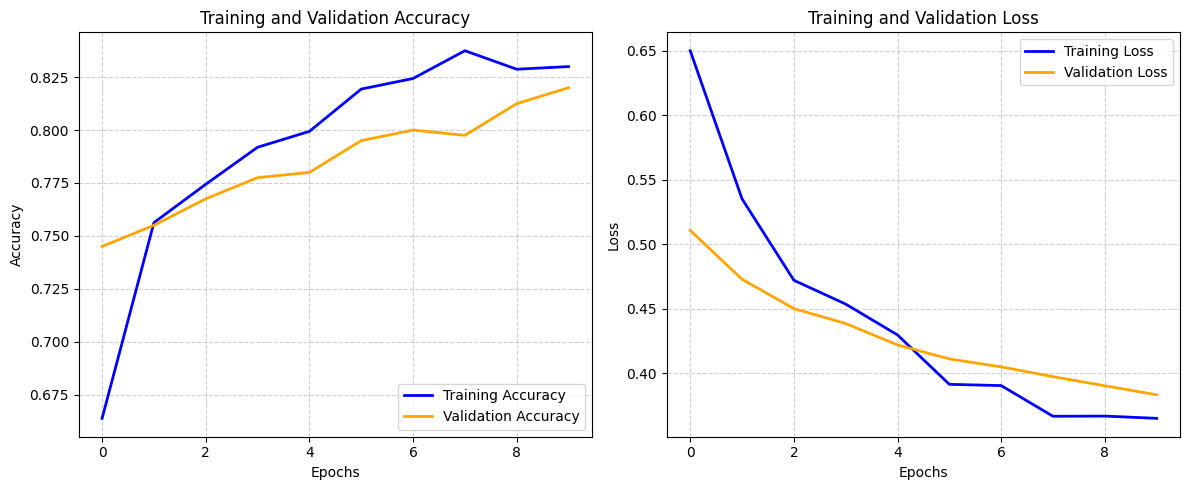

In [4]:
# Extract the data from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Create the Figure
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Loading Test Dataset

In [5]:
# Load the 100 images we moved to 'data/test' at the very start
test_ds = tf.keras.utils.image_dataset_from_directory(
    './test',
    image_size=(224, 224),
    batch_size=32
)

# The "Final Exam" - it returns [loss, accuracy]
results = model.evaluate(test_ds)
print(f"Test Accuracy: {results[1]*100:.2f}%")

Found 100 files belonging to 2 classes.


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.8400 - loss: 0.3613
Test Accuracy: 84.00%


Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


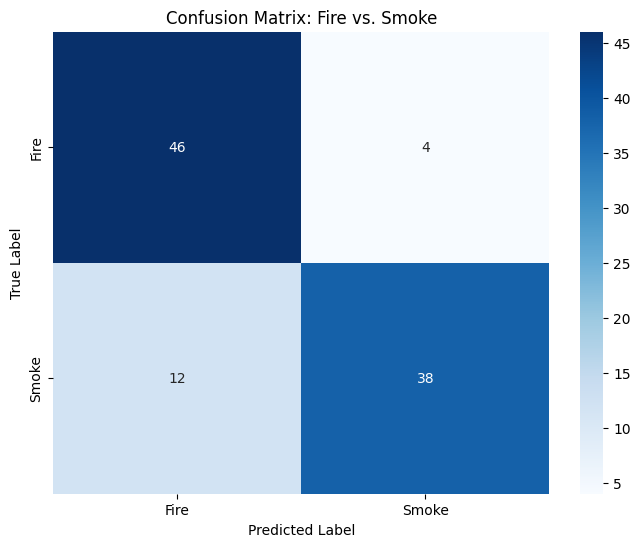

              precision    recall  f1-score   support

        Fire       0.79      0.92      0.85        50
       Smoke       0.90      0.76      0.83        50

    accuracy                           0.84       100
   macro avg       0.85      0.84      0.84       100
weighted avg       0.85      0.84      0.84       100



In [6]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get the True Labels and Model Predictions
# We'll use the test_ds (the 100 "Final Exam" images)
all_labels = []
all_preds = []

for images, labels in test_ds:
    # Predict the batch
    preds = model.predict(images)

    # Convert sigmoid probabilities (0.0 to 1.0) to hard classes (0 or 1)
    # If pred > 0.5, it's Class 1, else Class 0
    preds_hard = (preds > 0.5).astype(int)

    all_labels.extend(labels.numpy())
    all_preds.extend(preds_hard.flatten())

# 2. Calculate the Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Visualize with Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fire', 'Smoke'],
            yticklabels=['Fire', 'Smoke'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fire vs. Smoke')
plt.show()

# 4. Print the Detailed Report (Precision, Recall, F1-Score)
print(classification_report(all_labels, all_preds, target_names=['Fire', 'Smoke']))

In [7]:
#Save the model
model.save('./model/fire_smoke.keras')